In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [183]:
# os.environ.pop("DATASET_PATH")
# %env

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
dataset_path = os.getenv("DATASET_PATH")
os.chdir(dataset_path)

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [186]:
df = df.iloc[:,2:]
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [187]:
# train test split data
from sklearn.model_selection import train_test_split
X = df.drop(columns='Purchased')
y = df['Purchased']
X_train , X_test , y_train ,y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [188]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
scalar.fit(X_train)    # learns parameter
# scalar.fit(X_test)      # we only apply fit for training data
scalar.mean_

array([3.71000000e+01, 6.90571429e+04])

In [189]:
# transform train and test sets
X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

# transform gives numpy nd array
X_train_scaled[0:5]

array([[-0.97910042, -1.11059025],
       [-0.20357533,  0.0566968 ],
       [ 1.15359356, -1.19813678],
       [-0.20357533,  0.64034033],
       [-0.00969406,  0.17342551]])

In [190]:
# convert to dataframe 
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_test_scaled.head()

,Age,EstimatedSalary
0,-0.106635,-1.052226
1,0.184187,-0.235125
2,-0.106635,1.428259
3,0.184187,1.544988
4,-1.076041,1.428259


In [191]:
# diff between mean of x_train and X_train_scaled
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.100000,69057.142857
std,10.334062,34328.848528
min,18.000000,15000.000000
25%,29.000000,43000.000000
50%,37.000000,67000.000000
75%,43.500000,85000.000000
max,60.000000,150000.000000


In [192]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.0,-0.1
75%,0.6,0.5
max,2.2,2.4


### effect of scaling 

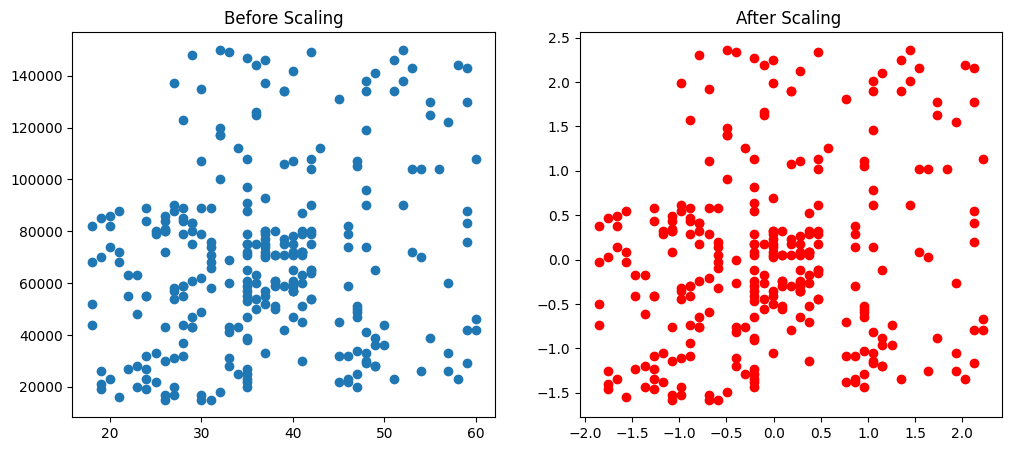

In [193]:
fig , ax = plt.subplots(ncols=2, figsize = (12,5))
ax[0].scatter(X_train['Age'],X_train['EstimatedSalary'])
ax[0].set_title("Before Scaling")
ax[1].scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],c='red')
ax[1].set_title("After Scaling ")
plt.show()

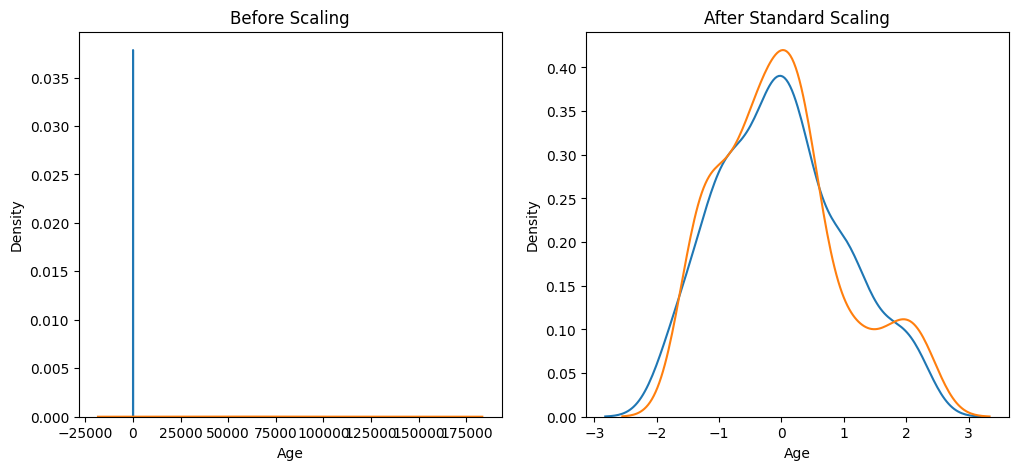

In [194]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

### Comparison of Distribution 

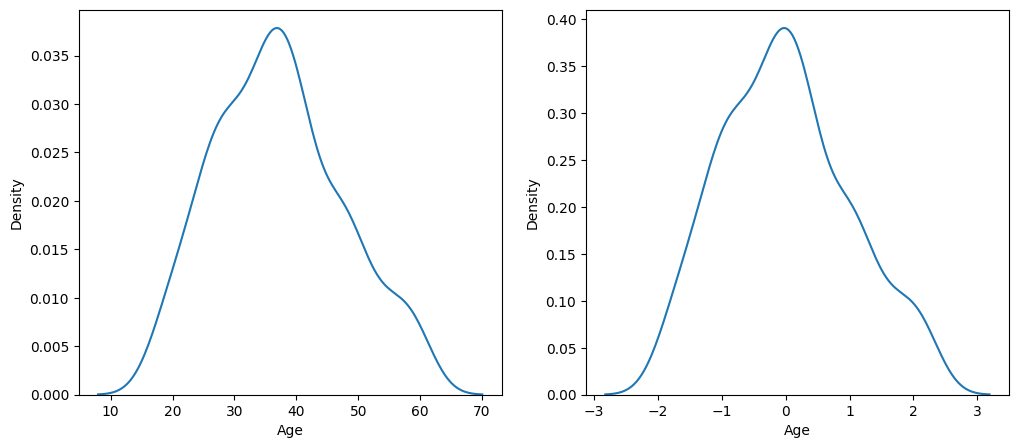

In [195]:
fig , (ax1,ax2) = plt.subplots(ncols=2, figsize = (12,5))

sns.kdeplot(data=X_train['Age'],ax = ax1)
sns.kdeplot(data=X_train_scaled['Age'],ax = ax2)
plt.show()

In [196]:
### why scaling is important

In [197]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression() 

In [198]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [199]:
# now predict
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy without scaling - ",accuracy_score(y_test,y_pred))
print("Accuracy with scaling - ",accuracy_score(y_test,y_pred_scaled))

Accuracy without scaling -  0.825
Accuracy with scaling -  0.825
